# [IAPR][iapr]: Lab 3 ‒  Classification


**Group ID:** xx

**Author 1 (sciper):** Student Name 1 (xxxxx)  
**Author 2 (sciper):** Student Name 2 (xxxxx)   
**Author 3 (sciper):** Student Name 3 (xxxxx)   

**Release date:** 19.04.2023  
**Due date:** 05.05.2023 


## Important notes

The lab assignments are designed to teach practical implementation of the topics presented during class well as
preparation for the final project, which is a practical project which ties together the topics of the course.

As such, in the lab assignments/final project, unless otherwise specified, you may, if you choose, use external
functions from image processing/ML libraries like opencv and sklearn as long as there is sufficient explanation
in the lab report. For example, you do not need to implement your own edge detector, etc.

**! Before handling back the notebook <font color='red'> rerun </font>the notebook from scratch !**
`Kernel` > `Restart & Run All`

We will not rerun the notebook for you.


[iapr]: https://github.com/LTS5/iapr

--
## 0. Setup

In [108]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In this lab, we will use PyTorch. If you are not familiar with this library, [here](https://pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html) is a quick tutorial of the basics.

In [109]:
import platform
print(platform.system())
if platform.system() == "Darwin":
    %pip install torch==1.8.1 torchvision==0.9.1
else:
    %pip install torch==1.8.1+cu111 torchvision==0.9.1+cu111 -f https://download.pytorch.org/whl/torch_stable.html

Linux
Looking in links: https://download.pytorch.org/whl/torch_stable.html
Note: you may need to restart the kernel to use updated packages.


In [110]:
import tarfile
import os

data_base_path = os.path.join(os.pardir, 'data')
data_folder = 'lab-03-data'
tar_path = os.path.join(data_base_path, data_folder + '.tar.gz')
with tarfile.open(tar_path, mode='r:gz') as tar:
    tar.extractall(path=data_base_path)

---
## Part 1 - Out-of-Distribution detection in colorectal cancer histology (12 points)

Colorectal cancer is one of the most widespread cancers for men and women. Diagnosis complemented with prognostic and predictive biomarker information is essential for patient monitoring and applying personalized treatments. A critical marker is the tumor/stroma ratio in unhealthy tissues sampled from the colon. The higher the ratio, the more invasive the cancer is. The degree of invasion is tightly linked to patient survial probability.

To measure the ratio, a pathologist needs to analyze the unhealthy tissue under a microscope and estimate it from a look. As the number of samples to analyze is huge and estimations are only sometimes precise, automatic recognition of the different tissue types in histological images has become essential. Such an automatic process requires the development of a multi-class classifier to identify the numerous tissues. As shown below, they are usually 8 tissue types to categorize: TUMOR, STROMA, LYMPHO (lymphocytes), MUCOSA, COMPLEX (complex stroma), DEBRIS, ADIPOSE and EMPTY (background).

<br />
<br />
<figure>
    <img src="../data/lab-03-data/part1/kather16.svg" width="1100">
    <center>
    <figcaption>Fig1: Collection of tissue types in colorectal cancer histology (Kather-16)</figcaption>
    </center>
</figure>
<br />
<br />


Up to this day, state-of-the-art methods use deep-learning-based supervised learning methods. A downfall of such an approach is the necessity to access a well-annotated training dataset. In histology, annotating data is difficult. It is time-consuming and requires the expertise of pathologists. Moreover, the annotator must label every tissue type while only two (TUMOR and STROMA) are interesting. 


Consequently, we propose another approach. In order to make the annotation task less tedious, we ask the annotator to label only the tissues of interest and dump the others. Then, we must train a binary classifier to automatically recognize these tissues at test time. In this part, you will implement the proposed approach.

### 1.1 Binary classifier with Mahalanobis distance (3 points)

Based on the abovementioned process, your task is to build a model that recognizes TUMOR (Label 0) and STROMA (Label 1) tissue types. Your model will be supervised by a training dataset containing TUMOR and STROMA annotations; note that all other tissues have been dropped.
We will not ask you to train a deep-learning-based binary classifier from scratch. Instead, we provide excellent features (descriptors) of the images we extracted from a visual foundation model. (Note: As the nature of the foundation model is not part of this lecture, feel free to ask TAs if you are curious).

Run the cell below to extract the provided train and test dataset. Each image is represented by a 768-d feature vector extracted from a visual foundation model. The train and test datasets contain feature vectors of 878 and 186 images respectively.

In [111]:
import torch 

# Label mapping
label_to_classname = {0 : "TUMOR", 1 : "STROMA"}

# Train features and labels
train_features = torch.load(os.path.join(data_base_path, data_folder, "part1/k16_train_features.pth"))
train_labels = torch.load(os.path.join(data_base_path, data_folder, "part1/k16_train_labels.pth"))

# Test features and labels
test_features = torch.load(os.path.join(data_base_path, data_folder, "part1/k16_test_features.pth"))
test_labels = torch.load(os.path.join(data_base_path, data_folder, "part1/k16_test_labels.pth"))

test_features.shape

torch.Size([186, 768])

**Task 1 (2.5 points)** Based on the training features (```train_features```) and training labels (```train_labels```), classify the test features (```test_features```) using minimum Mahalanobis distance.

*Note:* You are not allowed to use any prebuilt Mahalanobis distance function. Additionally, ```torch.cov``` is not defined to compute the covariance matrix. You can use ```sklearn.covariance.LedoitWolf``` instead.

In [112]:
### Task 1
from sklearn.covariance import LedoitWolf

def mahalanobis_distance(x, mean, cov_inv):
    """
    Computes the Mahalanobis distance for x
    :param x: example for which to compute Mahalanobis distance
    :param means: means of train set used to compute Mahalanobis distance
    :param cov_inverses: inverse covariance matrices of train set used to compute Mahalanobis distance
    :return: Mahalanobis distance for x
    """
    diff = x - mean
    md = torch.sqrt(torch.matmul(torch.matmul(diff, cov_inv), diff.t()))
    return md.item()

def classify(test_features, means, cov_inverses):
    """
    Classifies each example in test_features using min Mahalanobis distance
    :param test_features: examples to classify
    :param means: means of train set used to compute Mahalanobis distance
    :param cov_inverses: inverse covariance matrices of train set used to compute Mahalanobis distance
    :return: class label for each test example
    """
    predictions = []
    for test_feature in test_features:
        distances = []
        for i in range(len(means)):
            distance = mahalanobis_distance(test_feature, means[i], cov_inverses[i])
            distances.append(distance)
        predictions.append(torch.argmin(torch.tensor(distances)).item())
    return predictions

# Separate features and labels by class
tumor_features = train_features[train_labels == 0]
stroma_features = train_features[train_labels == 1]

# Calculate means and covariances
tumor_mean = torch.mean(tumor_features, dim=0)
stroma_mean = torch.mean(stroma_features, dim=0)
tumor_cov = torch.from_numpy(LedoitWolf().fit(tumor_features).covariance_)
stroma_cov = torch.from_numpy(LedoitWolf().fit(stroma_features).covariance_)

# Calculate inverses of covariance matrices
tumor_cov_inv = torch.inverse(tumor_cov)
stroma_cov_inv = torch.inverse(stroma_cov)

# Store means and cov_inverses in lists
means = [tumor_mean, stroma_mean]
cov_inverses = [tumor_cov_inv, stroma_cov_inv]

# Classify test features
test_predictions = classify(test_features, means, cov_inverses)
print(test_predictions)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


**Task 2 (0.5 points)** Compute the accuracy of your predictions with the test labels (```test_labels```).

In [113]:
### Task 2
print(f"Accuracy on the test set: {(test_predictions == test_labels).mean():.3f}")

Accuracy on the test set: 0.978


### 1.2 Out-of-Distribution detection with Mahalanobis distance (3 points)

You will note that the test you run above is not really realistic. Like the training set, it contains only the TUMOR and STROMA tissue types. Nevertheless, at test time, the other tissues (Label -1) are also present and cannot be filtered by hand. Moreover, they cannot be recognized by the model as they are out of the training distribution (It is the consequence of the laziness of the annotators ;)). For this reason, it is essential to filter them out. This task is called Out-of-Distribution (OoD) detection. 

A simple way to do OoD detection is to compute for every test example an OoD-ness score which should be low for In-Distribution (ID) examples and high for OoDs. Then we define a threshold from which every example with an OoD-ness lying above is discarded, and those lying below are forwarded to the model for prediction. An example of OoD-ness score is the minimum Mahalanobis distance.

Run the cell below to load a new test set containing OoD examples. It has 186 ID and 558 OoD examples.

In [114]:
label_to_classname_w_ood = {0 : "TUMOR", 1 : "STROMA", -1 : "OoD"}

# Test features and labels with OoD tissues
test_features_w_ood = torch.load(os.path.join(data_base_path, data_folder, "part1/k16_test2_features.pth"))
test_labels_w_ood = torch.load(os.path.join(data_base_path, data_folder,"part1/k16_test2_labels.pth"))

test_features_w_ood.shape

torch.Size([744, 768])

**Task 1 (0.5 point)** Why do you think the minimum Mahalanobis distance is a good OoD-ness score?

**Answer:** Because the minimum Mahalanobis distance is a good metric to compute distance to different classes, so if what is being classified is not similar to any class, then the value will be high so we can classify it as OoD. Also we are already computing minimum Mahalanobis distance for the classification, so this way we don't have to compute anything extra for the OoD detection.

**Task 2 (0.5 point)** Compute the minimum Mahalanobis distance for every test examples in ```test_features_w_ood``` with respect to the training features (```train_features```).

In [115]:
### Task 2
def min_mahalanobis_distances(test_features, means, cov_inverses):
    """
    Computes the minimum Mahalanobis distance for every example in test_features
    :param test_features: examples for which to compute min distance
    :param means: means of train set used to compute Mahalanobis distance
    :param cov_inverses: inverse covariance matrices of train set used to compute Mahalanobis distance
    :return: minimum Mahalanobis distance for every example in test_features
    """
    min_distances = []
    for test_feature in test_features:
        distances = []
        for i in range(len(means)):
            distance = mahalanobis_distance(test_feature, means[i], cov_inverses[i])
            distances.append(distance)
        min_distances.append(min(distances))
    return min_distances

# Compute minimum Mahalanobis distances
min_distances = min_mahalanobis_distances(test_features_w_ood, means, cov_inverses)
print(min_distances)

[33.81541442871094, 42.58422088623047, 37.88202667236328, 37.13945388793945, 23.729209899902344, 38.68918991088867, 38.278682708740234, 28.079008102416992, 33.11440658569336, 24.974878311157227, 31.218475341796875, 36.796875, 31.59029197692871, 33.40503692626953, 30.121753692626953, 35.96795654296875, 26.291603088378906, 34.539215087890625, 25.33297348022461, 27.153635025024414, 39.494850158691406, 30.458759307861328, 35.85584259033203, 34.00855255126953, 27.556665420532227, 38.53245544433594, 37.22294616699219, 40.864158630371094, 36.61758041381836, 36.903602600097656, 28.50161361694336, 31.586681365966797, 32.23159408569336, 30.18876838684082, 27.447141647338867, 26.896381378173828, 27.612215042114258, 30.99344253540039, 30.038503646850586, 34.0157585144043, 49.673824310302734, 22.106487274169922, 32.35665512084961, 30.797260284423828, 26.824853897094727, 33.42808151245117, 36.88309097290039, 31.217166900634766, 42.414947509765625, 34.07392883300781, 33.91841125488281, 27.66563415527

**Task 3 (0.5 point)** Plot a histogram to show the difference between the Mahalanobis distance of TUMOR, STROMA and OoD tissue types and comment on what you observe.

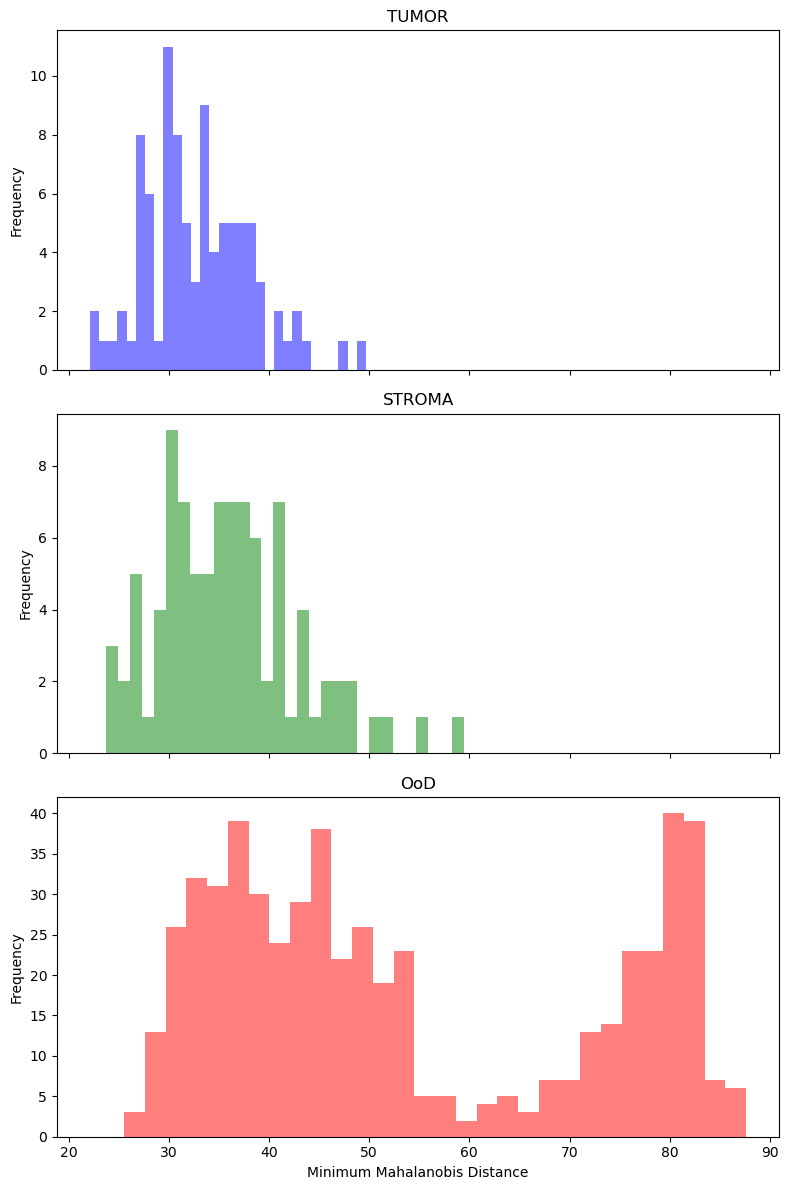

In [116]:
### Task 3
import matplotlib.pyplot as plt

# Separate test examples by tissue type
tumor_test_features = test_features_w_ood[test_labels_w_ood == 0]
stroma_test_features = test_features_w_ood[test_labels_w_ood == 1]
ood_test_features = test_features_w_ood[test_labels_w_ood == -1]

# Compute minimum Mahalanobis distances for each tissue type
tumor_min_distances = min_mahalanobis_distances(tumor_test_features, means, cov_inverses)
stroma_min_distances = min_mahalanobis_distances(stroma_test_features, means, cov_inverses)
ood_min_distances = min_mahalanobis_distances(ood_test_features, means, cov_inverses)

# Plot histograms
fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

# TUMOR histogram
axs[0].hist(tumor_min_distances, bins=30, alpha=0.5, label='TUMOR', color='blue')
axs[0].set_title('TUMOR')
axs[0].set_ylabel('Frequency')

# STROMA histogram
axs[1].hist(stroma_min_distances, bins=30, alpha=0.5, label='STROMA', color='green')
axs[1].set_title('STROMA')
axs[1].set_ylabel('Frequency')

# OoD histogram
axs[2].hist(ood_min_distances, bins=30, alpha=0.5, label='OoD', color='red')
axs[2].set_title('OoD')
axs[2].set_xlabel('Minimum Mahalanobis Distance')
axs[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observations:**
We observe the following:
- The OoD tissue types tend to have higher minimum Mahalanobis distances, suggesting that they lie further away from the known class means. This confirms the idea that the minimum Mahalanobis distance can be a good indicator of OoD-ness.
- There is some overlap between the minimum Mahalanobis distances of different tissue types. This overlap indicates we need to be careful in choosing a threshold for OoD detection to achieve a good balance between filtering out OoD examples and retaining true TUMOR and STROMA examples.

**Task 4 (1 point)** Find a threshold on the Mahalanobis distance such that 95% of the OoD examples are filtered out. How much TUMOR and STROMA have also been filtered out?

In [117]:
### Task 4
import numpy as np

# Find the 95th percentile value for OoD distances
ood_threshold = np.percentile(ood_min_distances, 5)

# Filter out examples with Mahalanobis distance greater than the threshold
filtered_tumor = [dist for dist in tumor_min_distances if dist > ood_threshold]
filtered_stroma = [dist for dist in stroma_min_distances if dist > ood_threshold]

# Calculate the proportion of TUMOR and STROMA examples filtered out
filtered_tumor_percentage = len(filtered_tumor) / len(tumor_min_distances) * 100
filtered_stroma_percentage = len(filtered_stroma) / len(stroma_min_distances) * 100

print("Threshold:", ood_threshold)
print(f"Percentage of TUMOR filtered out: {filtered_tumor_percentage:.2f}%")
print(f"Percentage of STROMA filtered out: {filtered_stroma_percentage:.2f}%")

Threshold: 30.76950912475586
Percentage of TUMOR filtered out: 61.29%
Percentage of STROMA filtered out: 74.19%


**Task 5 (0.5 point)** Assign prediction -1 to filtered out examples and compute the average class-wise accuracy of your prediction with test labels (```test_labels_w_ood```). Is it satisfactory?

In [118]:
### Task 5
def classwise_accuracy(predictions, true_labels, target_class):
    """
    Computes the accuracy for a single class
    :param predictions: predicted class labels
    :param true_labels: true class labels
    :param target_class: label of the class we want to compute accuracy of
    :return: accuracy for target_class
    """
    correct = 0
    total = 0
    for i in range(len(predictions)):
        if true_labels[i].item() == target_class:
            total += 1
            if predictions[i] == true_labels[i].item():
                correct += 1
    return correct / total if total > 0 else None

# Assign -1 to filtered out examples
filtered_predictions = []
for i, test_feature in enumerate(test_features_w_ood):
    min_distance = min_mahalanobis_distances([test_feature], means, cov_inverses)[0]
    if min_distance > ood_threshold:
        filtered_predictions.append(-1)
    else:
        filtered_predictions.append(classify([test_feature], means, cov_inverses)[0])

# Compute class-wise accuracies
tumor_accuracy = classwise_accuracy(filtered_predictions, test_labels_w_ood, 0)
stroma_accuracy = classwise_accuracy(filtered_predictions, test_labels_w_ood, 1)
ood_accuracy = classwise_accuracy(filtered_predictions, test_labels_w_ood, -1)

# Compute average class-wise accuracy
average_accuracy = np.nanmean([tumor_accuracy, stroma_accuracy, ood_accuracy])

print(f"TUMOR Accuracy: {tumor_accuracy:.2f}")
print(f"STROMA Accuracy: {stroma_accuracy:.2f}")
print(f"OoD Accuracy: {ood_accuracy:.2f}")
print(f"Average Class-wise Accuracy: {average_accuracy:.2f}")

TUMOR Accuracy: 0.39
STROMA Accuracy: 0.26
OoD Accuracy: 0.95
Average Class-wise Accuracy: 0.53


While many of the OoD examples are being filtered out, as a result the accuracy for classifying the TUMOR and STROMA classes is quite low. This is because there is some significant overlap in the values for minimum Mahalanobis distance between in-distribution and out-of-distribution examples. So the results are not very satisfactory. To improve them we might reduce the threshold so that only 90% of OoD examples are filtered out, which could improve the overall accuracy.

### 1.3 Out-of-distribution detection with k-NN classifier (6 points)

The visual foundation models are known to be very good k-NN classifiers. It motivates us to implement a k-NN classifier to recognize TUMOR and STROMA. Moreover, k-NN distance is a good OoD-ness score and suits our task.

**Task 1 (2 points)** Based on the training features (```train_features```) and training labels (```train_labels```), classify the test features (```test_features```) using a k-NN classifier. Then report the accuracy of your predictions with the test labels (```test_labels```).

*Note:* The choice of `k` is up to you.

In [119]:
### Task 1
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Initialize k-NN classifier
k = 3
knn_classifier = KNeighborsClassifier(n_neighbors=k)

# Train the classifier
knn_classifier.fit(train_features, train_labels)

# Predict test features
knn_predictions = knn_classifier.predict(test_features)

# Calculate accuracy
knn_accuracy = accuracy_score(test_labels, knn_predictions)

print(f"k-NN Accuracy: {knn_accuracy:.2f}")

k-NN Accuracy: 1.00


**Task 2 (2 points)** Perform OoD detection on the test features (```test_features_w_ood```) using a k-NN distance based OoD-ness score. Find a threshold on your OoD-ness score such that 95% of the OoD examples are filtered out. How much TUMOR and STROMA have also been filtered out? Finally, assign prediction -1 to filter out examples and compute the average class-wise accuracy of your prediction with test labels (```test_labels_w_ood```).

*Note:* The OoD-ness is based on the distance to the k-nearest neighbors. The formulation is up to you. You have to justify your choice.

As an OoD-ness score, we use the mean distance to the k-nearest neighbors. Since the training set only contains in-distribution examples, OoD examples in the test set will be generally farther away from those than in-distribution examples in the test set.

In [120]:
### Task 2
# Compute the k-NN distances for test_features_w_ood
knn_distances, _ = knn_classifier.kneighbors(test_features_w_ood)
average_knn_distances = np.mean(knn_distances, axis=1)

# Calculate the OoD-ness score threshold
ood_knn_threshold = np.percentile(average_knn_distances[test_labels_w_ood == -1], 5)

# Filter out examples with OoD-ness score greater than the threshold
filtered_tumor_knn = [dist for i, dist in enumerate(average_knn_distances) if dist > ood_knn_threshold and test_labels_w_ood[i] == 0]
filtered_stroma_knn = [dist for i, dist in enumerate(average_knn_distances) if dist > ood_knn_threshold and test_labels_w_ood[i] == 1]

# Calculate the proportion of TUMOR and STROMA examples filtered out
filtered_tumor_knn_percentage = len(filtered_tumor_knn) / (test_labels_w_ood == 0).sum().item() * 100
filtered_stroma_knn_percentage = len(filtered_stroma_knn) / (test_labels_w_ood == 1).sum().item() * 100

print("k-NN OoD Threshold:", ood_knn_threshold)
print(f"Percentage of TUMOR filtered out: {filtered_tumor_knn_percentage:.2f}%")
print(f"Percentage of STROMA filtered out: {filtered_stroma_knn_percentage:.2f}%")

k-NN OoD Threshold: 42.67083181419321
Percentage of TUMOR filtered out: 67.74%
Percentage of STROMA filtered out: 46.24%


In [121]:
# Assign -1 to filtered out examples and predict others
filtered_knn_predictions = []
for i, test_feature in enumerate(test_features_w_ood):
    if average_knn_distances[i] > ood_knn_threshold:
        filtered_knn_predictions.append(-1)
    else:
        filtered_knn_predictions.append(knn_classifier.predict(test_feature.unsqueeze(0))[0])

# Compute class-wise accuracies
tumor_knn_accuracy = classwise_accuracy(filtered_knn_predictions, test_labels_w_ood, 0)
stroma_knn_accuracy = classwise_accuracy(filtered_knn_predictions, test_labels_w_ood, 1)
ood_knn_accuracy = classwise_accuracy(filtered_knn_predictions, test_labels_w_ood, -1)

# Compute average class-wise accuracy
average_knn_accuracy = np.nanmean([tumor_knn_accuracy, stroma_knn_accuracy, ood_knn_accuracy])

print(f"TUMOR k-NN Accuracy: {tumor_knn_accuracy:.2f}")
print(f"STROMA k-NN Accuracy: {stroma_knn_accuracy:.2f}")
print(f"OoD k-NN Accuracy: {ood_knn_accuracy:.2f}")
print(f"Average Class-wise k-NN Accuracy: {average_knn_accuracy:.2f}")

TUMOR k-NN Accuracy: 0.32
STROMA k-NN Accuracy: 0.54
OoD k-NN Accuracy: 0.95
Average Class-wise k-NN Accuracy: 0.60


**Task 3 (1 point)** Is k-NN better than Mahalanobis distance ? Make an hypothesis for the reasons.

**Answer:**
In our case, k-NN (60% accuracy) performs better than Mahalanobis distance (53% accuracy) while filtering out the same number of OoD examples. Some hypotheses for this result are:
- Sensitivity to the distribution of the data: Mahalanobis distance works with the overall mean and covariance of the data, while k-NN relies on local neighborhood information. If the data distribution is highly non-linear or has complex structures, k-NN might capture the local variations better than Mahalanobis distance.
- Assumptions about class distribution: Mahalanobis distance assumes that the classes have a Gaussian distribution, which may not be the case for the given data. k-NN, on the other hand, makes no such assumptions and can adapt better to different class distributions.
- Outliers and noise: k-NN can be more robust to outliers and noise, as it is based on local neighborhood information. If a few training examples are noisy or have incorrect labels, Mahalanobis distance might be more sensitive to these issues due to its reliance on the global covariance.

**Task 4 (1 point)** Do you think we can suggest the approach presented in this exercise to compute TUMOR/STROMA ratio automatically ? Justify your thoughs. If not, suggest at least two ideas to improve it.

*Note:* Annotating all the training dataset is not an option.

**Answer:** Even though k-NN performs better than Mahalanobis distance, both of these methods have relatively low accuracies. Indeed, the overall accuracy of k-NN is 60% which is probably not enough to compute TUMOR/STROMA ratio automatically and get reliably good results.

Since discriminating between TUMOR and STROMA classes is already done perfectly by the k-NN classifier, there is not any room for improvement there. Instead, what has to be improved is the filtering out of OoD examples. Indeed, for now, too many in-distribution examples are being falsely recognized as OoD. For now we are just using a simple threshold so some ideas to improve that could be:
- use a more complex method such as training a separate model to recognize OoD examples
- tune the value of k in k-NN
- try other classification algorithms than k-NN, such as SVM, ensemble methods or a neural network.

---

## Part 2 (12 points)
In this part, we aim to classify cervical cells resulting from Pap smear tests. To that end we'll be using a publicly available cell dataset: Sipakmed (https://www.cs.uoi.gr/~marina/sipakmed.html). The dataset is composed of 4049 images of isolated cells cropped from 966 cluster cell images of Pap smear slides. Each cell in the dataset has been categorized in either of the following categories: 

    - Superficial-Intermediate.
    - Parabasal.
    - Koilocytotic.
    - Dysketarotic.
    - Metaplastic.
Your objective is to implement a classifier to automate the cell classification process. To ease your work we provide you with pre-computed embeddings for each images (`lab-03-data/part2/sipakmed_clean_embeddings.pth`). The embeddings are obtained from a pre-trained ResNet-50 (https://arxiv.org/pdf/1512.03385.pdf) and the corresponding images are also provided (`lab-03-data/part2/sipakmed_clean`). Note that you are free to discard the provided embeddings and work directy with the images.

### 2.1 Dataset (4 points)
Your first task is prepare the dataset such that it can be used to train your model. For that purpose we prepared the skeleton of the class `Sipakmed` that inherits from the class `Dataset` of PyTorch. Read the documentation (https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#creating-a-custom-dataset-for-your-files) and complete the missing parts.

In [122]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import os
from torch import nn
from collections import OrderedDict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

import math

In [123]:
# Load the features
features_path = '../data/lab-03-data/part2/sipakmed_clean_embeddings.pth'

In [124]:
class Sipakmed(Dataset):
    phase_dict = {
            'train': {'start': 0.0, 'stop': 0.5},
            'val': {'start': 0.5, 'stop': 0.75},
            'test': {'start': 0.75, 'stop': 1.0}
    }
    label_dict = {
        'im_Superficial-Intermediate': 0,
        'im_Parabasal': 1, 
        'im_Metaplastic': 2,
        'im_Koilocytotic': 3,
        'im_Dyskeratotic': 4
    }
    
    def __init__(self, features_path, phase):

        super(Sipakmed, self).__init__()
        # Store class attributes
        self.phase = phase
        
        # Collect the data
        import torch.nn.functional as F
        import numpy as np
        self.raw_data = torch.load(features_path)
        self.features, self.labels, self.paths = self.collect_data()
        
    def collect_data(self):
        # Iterate over the dirs/classes
        features, labels, paths = [], [], []
        for dir_name, dir_dict in self.raw_data.items():
            # Get the paths and embeddings
            dir_paths, dir_embeddings = list(zip(*[(k, v) for k, v in dir_dict.items()]))
            
            # Split
            n = len(dir_paths)
            np.random.seed(42)
            permutations = np.random.permutation(n)
            dir_paths = np.array(dir_paths)[permutations]
            dir_embeddings = torch.stack(dir_embeddings)[permutations]
            n_start = int(n * self.phase_dict[self.phase]['start'])
            n_stop = int(n * self.phase_dict[self.phase]['stop'])
            dir_embeddings = dir_embeddings[n_start: n_stop]
            dir_paths = dir_paths[n_start: n_stop]
    
            # Store
            features.append(dir_embeddings)
            paths.append(dir_paths)
            dir_labels = torch.tensor([self.label_dict[p.split('/')[-2]] for p in dir_paths])
            labels.append(dir_labels)
            
        # Merge
        features = torch.cat(features)
        labels = torch.cat(labels)
        paths = np.concatenate(paths)
        return features, labels, paths
            
        
    def __len__(self,):
        """
        Returns the number of samples in the dataset.
        """
        return len(self.features)
    
    def __getitem__(self, index):
        """
        Returns the embedding, label, and image path of queried index.
        """
        embedding = self.features[index]
        label = self.labels[index]
        path = self.paths[index]
        return embedding, label, path

Once the implementation of `Sipakmed` completed, create 3 instances of the class (train/val/test) with the corresponding `phase` flag.

In [125]:
# Instantiate the datasets
train_dataset = Sipakmed(features_path, "train")
val_dataset = Sipakmed(features_path, "val")
test_dataset = Sipakmed(features_path, "test")

Now that your datasets are ready, use the class `DataLoader` from PyTorch to let it handle efficiently the batching, shuffling, etc. of your data.

In [126]:
# Instantiate the data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

Get to know your data. Plot a few example images for each class of your dataset.

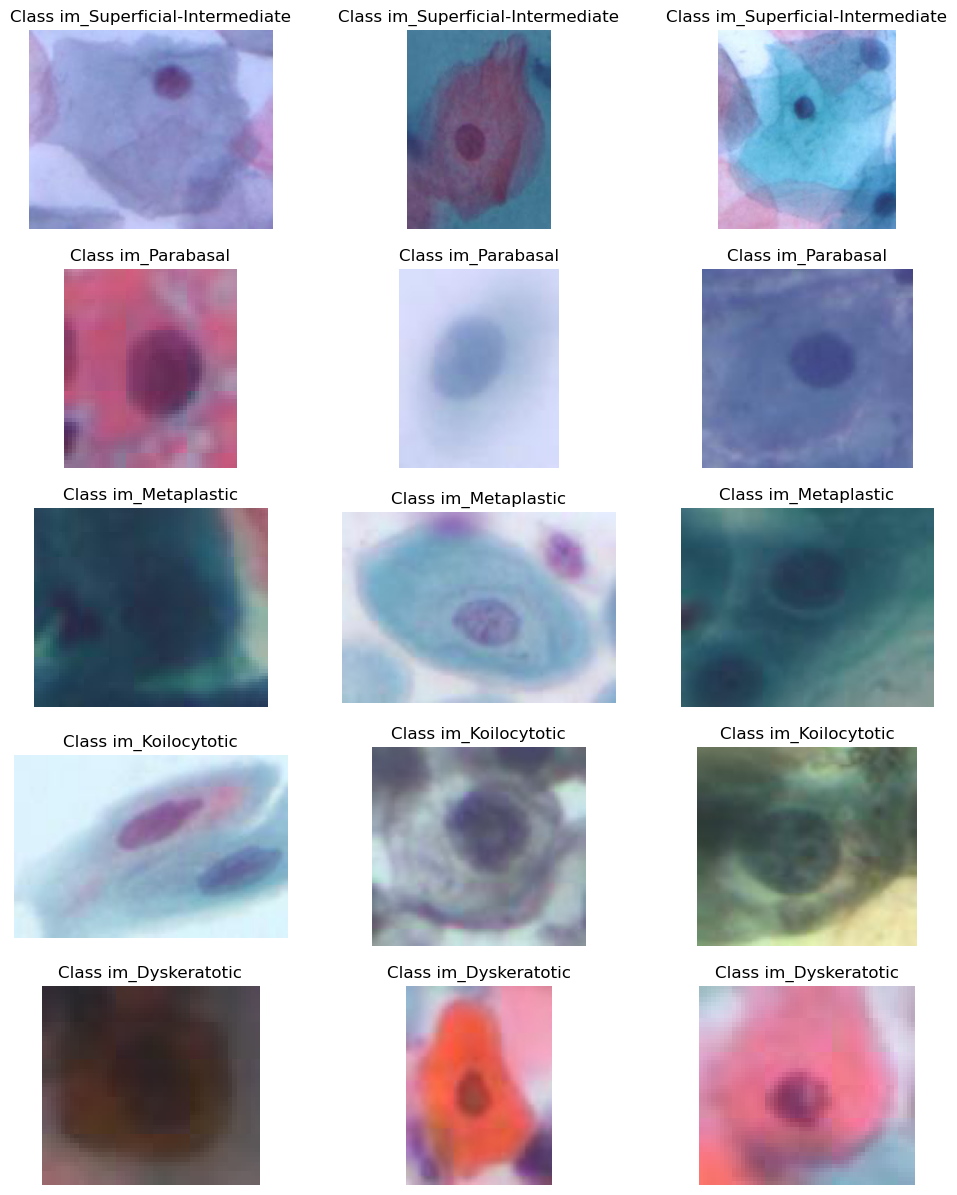

In [127]:
# Visualize some training example
def plot_example_images(dataset, num_examples=3):
    class_examples = {class_:train_dataset.paths[train_dataset.labels==label][:num_examples] for class_,label in train_dataset.label_dict.items()}

    num_classes = len(class_examples)
    fig, axes = plt.subplots(num_classes, num_examples, figsize=(num_examples * 4, num_classes * 3))

    for i, (label, examples) in enumerate(class_examples.items()):
        for j, path in enumerate(examples):
            img = Image.open('../data/lab-03-data/part2/'+path)
            axes[i, j].imshow(np.array(img))
            axes[i, j].set_title(f"Class {label}")
            axes[i, j].axis("off")

    plt.show()

# Plot example images for each class in the train dataset
plot_example_images(train_dataset)

### 2.2 Training (4 points)
In this part your objective is to implement the required tools to train your model. The first thing you'll need is a a model which takes as input the pre-computed features and returns the corresponding class probabilities/logits.

In [128]:
# Implement the model
embedding_dim = train_dataset.features.shape[1]
num_classes = len(train_dataset.label_dict)

model = nn.Sequential(
    nn.Linear(embedding_dim, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
)

The optimizer will keep track of your model's parameters, gradients, etc (https://pytorch.org/docs/stable/optim.html). It is responsible to update your model's parameters after each forward pass using the backpropagation algorithm.

In [129]:
import torch.optim as optim

# Set the optimizer
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [130]:
# Set the loss
criterion = nn.CrossEntropyLoss()

Implement a function that takes as input the model's output and the corresponding labels and returns the perçentage of correct predictions.

In [131]:
def accuracy(outputs, labels):
    """
    Computes the accuracy of predictions based on the model outputs (NxK: N samples, K classes) 
    and the labels (N: N samples).
    """
    # Get the class with the highest predicted probability
    _, predicted = torch.max(outputs, 1)

    # Count the number of correct predictions
    correct = (predicted == labels).sum().item()

    # Calculate the accuracy
    acc = correct / labels.size(0)

    return acc

Implement a funtion `train` that forwards the complete training set through your model (= 1 epoch) and updates its parameters after each forward pass. To keep track of the training process make sure to at least return the accuracy of the model and the average loss it incurred through the current epoch.

In [132]:
def train(model, optimizer, criterion, loader):
    # Set the model in train mode
    model.train()

    # Iterate over the batches
    full_outputs = []
    full_labels = []
    losses = []
    for batch in loader:
        # Get the embeddings, labels and paths
        embeddings, labels, _ = batch

        # Feed the embeddings to the model
        outputs = model(embeddings)

        # Compute cross entropy loss
        loss = criterion(outputs, labels)

        # Reset the gradients
        optimizer.zero_grad()

        # Backpropagate
        loss.backward()

        # Update the parameters
        optimizer.step()

        # Store the outputs, labels and loss
        full_outputs.append(outputs.detach())
        full_labels.append(labels.detach())
        losses.append(loss.detach())

    # Concat
    full_outputs = torch.cat(full_outputs).cpu()
    full_labels = torch.cat(full_labels).cpu()
    losses = torch.stack(losses).mean().cpu()

    # Compute the accuracy
    acc = accuracy(full_outputs, full_labels)
    return acc, full_outputs, full_labels, losses

Implement a funtion `validate` that forwards the complete validation or test set through your model and evaluates its predictions. To keep track of the training process make sure to at least return the accuracy of the model and the average loss it incurred through the current epoch.

In [133]:
@torch.no_grad()
def validate(model, criterion, loader):
    # Set the model in evaluation mode
    model.eval()

    # Iterate over the batches
    full_outputs = []
    full_labels = []
    full_paths = []
    losses = []
    for batch in loader:
        # Get the embeddings, labels and paths
        embeddings, labels, paths = batch

        # Feed the embeddings to the model
        outputs = model(embeddings)

        # Compute cross entropy loss
        loss = criterion(outputs, labels)

        # Store the outputs, labels and loss
        full_outputs.append(outputs.detach())
        full_labels.append(labels.detach())
        losses.append(loss.detach())
        full_paths.append(paths)

    # Concat
    full_outputs = torch.cat(full_outputs).cpu()
    full_labels = torch.cat(full_labels).cpu()
    losses = torch.stack(losses).mean().cpu()
    full_paths = np.concatenate(full_paths)

    # Compute the accuracy
    acc = accuracy(full_outputs, full_labels)
    return acc, full_outputs, full_labels, losses, full_paths

You should now be able to train you model. Alternate between training and validation steps to find and save the best model (best accuracy on the validation set).

In [134]:
# Main loop
epochs = 10
best_acc = 0
model_savepath = '../data'

for epoch in range(epochs):
    # Train
    train_acc, train_outputs, train_labels, train_loss = train(model, optimizer, criterion, train_loader)

    # Evaluate
    val_acc, val_outputs, val_labels, val_loss, val_paths = validate(model, criterion, val_loader)

    # Save the model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), os.path.join(model_savepath, 'best_model.pth'))

    # Print the results
    print(f'Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Train Accuracy: {train_acc:.4f} - Val Loss: {val_loss:.4f} - Val Accuracy: {val_acc:.4f}')

Epoch 1/10 - Train Loss: 0.4412 - Train Accuracy: 0.8536 - Val Loss: 0.2750 - Val Accuracy: 0.8992
Epoch 2/10 - Train Loss: 0.1341 - Train Accuracy: 0.9530 - Val Loss: 0.2208 - Val Accuracy: 0.9259
Epoch 3/10 - Train Loss: 0.0782 - Train Accuracy: 0.9743 - Val Loss: 0.2001 - Val Accuracy: 0.9328
Epoch 4/10 - Train Loss: 0.0430 - Train Accuracy: 0.9827 - Val Loss: 0.1924 - Val Accuracy: 0.9387
Epoch 5/10 - Train Loss: 0.0246 - Train Accuracy: 0.9906 - Val Loss: 0.1862 - Val Accuracy: 0.9457
Epoch 6/10 - Train Loss: 0.0084 - Train Accuracy: 0.9995 - Val Loss: 0.2291 - Val Accuracy: 0.9368
Epoch 7/10 - Train Loss: 0.0043 - Train Accuracy: 1.0000 - Val Loss: 0.2249 - Val Accuracy: 0.9447
Epoch 8/10 - Train Loss: 0.0021 - Train Accuracy: 1.0000 - Val Loss: 0.2283 - Val Accuracy: 0.9457
Epoch 9/10 - Train Loss: 0.0015 - Train Accuracy: 1.0000 - Val Loss: 0.2361 - Val Accuracy: 0.9427
Epoch 10/10 - Train Loss: 0.0010 - Train Accuracy: 1.0000 - Val Loss: 0.2376 - Val Accuracy: 0.9457


### 2.3 Evaluation (4 points)
Re-load the best model and evaluate its predictions on the test set.

In [135]:
# Re-load the best model
best_model = nn.Sequential(
    nn.Linear(embedding_dim, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
)
best_model.load_state_dict(torch.load(os.path.join(model_savepath, 'best_model.pth')))

# Evaluate
test_acc, test_outputs, test_labels, test_loss, test_paths = validate(best_model, criterion, test_loader)

# Print the test results
print(f'Test Loss: {test_loss:.4f} - Test Accuracy: {test_acc:.4f}')

Test Loss: 0.2048 - Test Accuracy: 0.9517


A useful tool to analyze your model's performance on the different classes is the confusion matrix (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html). Computes its entries for your model and the test set.

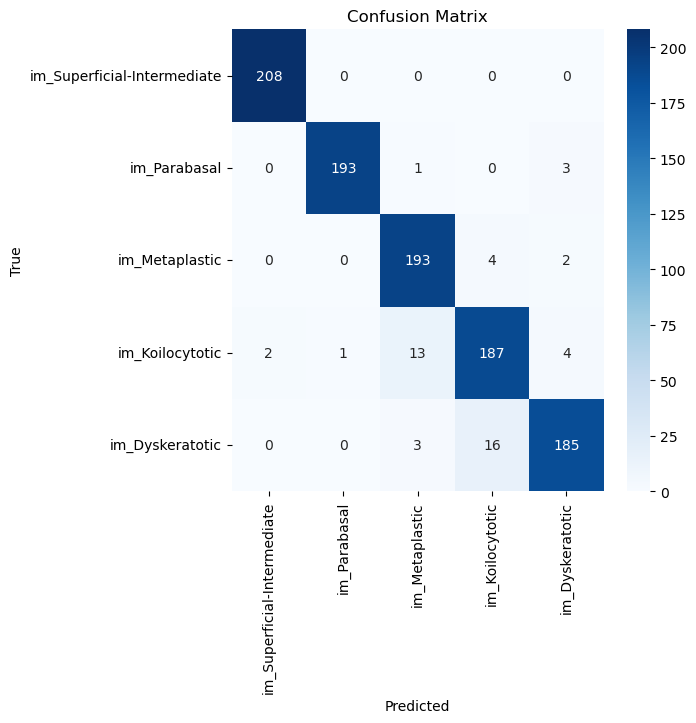

In [136]:
# Display the confusion matrix

# Compute the confusion matrix
cm = confusion_matrix(test_labels, test_outputs.argmax(dim=1))

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=train_dataset.label_dict.keys(), yticklabels=train_dataset.label_dict.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Alternatively it can be useful to plot the problematic samples as well as the predicted and ground truth classes. Can you do so?

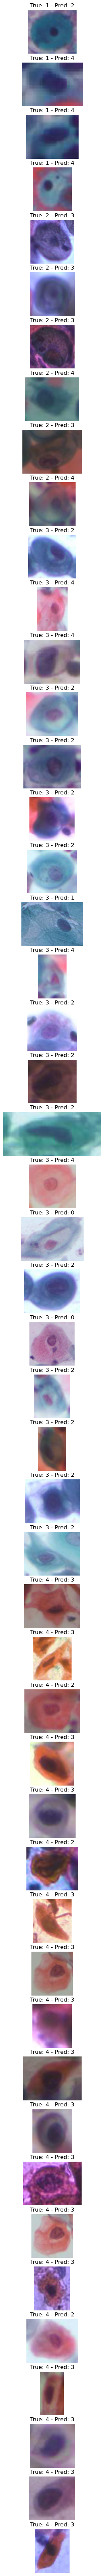

In [137]:
# Find the misclassified samples
misclassified = test_paths[test_labels != test_outputs.argmax(dim=1)]

# Plot the misclassified samples
fig, axes = plt.subplots(len(misclassified), figsize=(5, 100))
for i in range(len(misclassified)):
    img = Image.open('../data/lab-03-data/part2/'+misclassified[i])
    axes[i].imshow(np.array(img))
    axes[i].axis("off")
    axes[i].set_title(f'True: {test_labels[test_paths == misclassified[i]].item()} - Pred: {test_outputs[test_paths == misclassified[i]].argmax(dim=1).item()}')
plt.show()